In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# imports
import os, time, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [3]:
DATA_ROOT    = '/content/drive/MyDrive/Datasets/PlantDoc/processed'
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_EPOCHS   = 40
LR_MAX       = 3e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
DROPOUT_P    = 0.3
NUM_WORKERS  = 2

NUM_CLASSES = len(os.listdir(os.path.join(DATA_ROOT, 'train')))
print(f'Classes found: {NUM_CLASSES}')

Classes found: 6


In [4]:
#Transforms
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [6]:
# Datasets & Loaders
train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, 'val'),   transform=val_tf)

class_counts   = np.bincount(train_ds.targets)
class_weights  = 1.0 / class_counts
sample_weights = class_weights[train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                      sampler=sampler, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Classes: {train_ds.classes}')

Train: 4620 | Val: 58
Classes: ['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Septoria Leaf Spot', 'Yellow Leaf Curl Virus']


In [7]:
# ResNet-18 from Scratch
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = F.relu(out, inplace=True)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT_P):
        super().__init__()
        self.in_ch = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(64,  2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(512, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def _make_layer(self, out_ch, num_blocks, stride):
        layers = [BasicBlock(self.in_ch, out_ch, stride)]
        self.in_ch = out_ch
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)


model = ResNet18().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total/1e6:.2f}M')

Total parameters: 11.18M


In [ ]:
# Loss / Optimizer / Scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

optimizer = AdamW(model.parameters(), lr=LR_MAX / 25, weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(
    optimizer,
    max_lr=LR_MAX,
    steps_per_epoch=len(train_dl),
    epochs=NUM_EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

scaler = GradScaler()

In [ ]:
#training loop
# replace your training loop cell with this

from tqdm import tqdm

def run_epoch(model, loader, criterion, optimizer, scheduler, scaler, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    desc = 'Train' if train else 'Val'
    pbar = tqdm(loader, desc=desc, leave=False, ncols=80)

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in pbar:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
            else:
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)

            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

            pbar.set_postfix(loss=f'{total_loss/total:.4f}',
                             acc=f'{correct/total:.2%}')

    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc, best_wts = 0.0, copy.deepcopy(model.state_dict())

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler, scaler, train=True)
    va_loss, va_acc = run_epoch(model, val_dl,   criterion, optimizer, scheduler, scaler, train=False)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        best_wts = copy.deepcopy(model.state_dict())
        tag = ' ★'
    else:
        tag = ''


    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_acc,
        'history': history
    }, '/content/drive/MyDrive/Datasets/PlantDoc/checkpoint_latest.pth')

    print(f'  checkpoint saved (epoch {epoch})')

    print(f'Epoch {epoch:>3}  '
          f'TrLoss={tr_loss:.4f}  TrAcc={tr_acc:.2%}  '
          f'VaLoss={va_loss:.4f}  VaAcc={va_acc:.2%}  '
          f'{elapsed:.0f}s{tag}')

print(f'\nBest val accuracy: {best_acc:.4%}')

  checkpoint saved (epoch 1)
Epoch   1  TrLoss=1.6900  TrAcc=29.42%  VaLoss=1.7862  VaAcc=29.31%  947s ★


  checkpoint saved (epoch 2)
Epoch   2  TrLoss=1.6197  TrAcc=34.63%  VaLoss=1.7664  VaAcc=29.31%  374s


  checkpoint saved (epoch 3)
Epoch   3  TrLoss=1.6026  TrAcc=37.36%  VaLoss=1.8715  VaAcc=25.86%  177s


  checkpoint saved (epoch 4)
Epoch   4  TrLoss=1.5999  TrAcc=37.36%  VaLoss=1.8462  VaAcc=27.59%  94s


  checkpoint saved (epoch 5)
Epoch   5  TrLoss=1.6099  TrAcc=37.32%  VaLoss=2.5520  VaAcc=24.14%  62s


...

  checkpoint saved (epoch 36)
Epoch  36  TrLoss=0.9504  TrAcc=74.52%  VaLoss=1.2779  VaAcc=65.52%  28s ★


  checkpoint saved (epoch 37)
Epoch  37  TrLoss=0.9500  TrAcc=75.00%  VaLoss=1.2473  VaAcc=65.52%  28s


  checkpoint saved (epoch 38)
Epoch  38  TrLoss=0.9232  TrAcc=75.95%  VaLoss=1.2735  VaAcc=63.79%  28s


  checkpoint saved (epoch 39)
Epoch  39  TrLoss=0.9339  TrAcc=75.22%  VaLoss=1.2546  VaAcc=65.52%  28s


  checkpoint saved (epoch 40)
Epoch  40  TrLoss=0.9331  TrAcc=76.19%  VaLoss=1.2677  VaAcc=67.24%  28s ★

Best val accuracy: 67.2414%


In [ ]:
# Resuming training from checkpoint
checkpoint = torch.load('/content/drive/MyDrive/Datasets/PlantDoc/checkpoint_latest.pth')
model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])
best_acc  = checkpoint['best_val_acc']
history   = checkpoint['history']
start_epoch = checkpoint['epoch'] + 1

print(f'Resuming from epoch {start_epoch}, best acc so far: {best_acc:.4%}')

EXTRA_EPOCHS = 20

# Fresh scheduler for fine-tuning
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EXTRA_EPOCHS, eta_min=1e-6
)

best_wts = copy.deepcopy(model.state_dict())

for epoch in range(start_epoch, start_epoch + EXTRA_EPOCHS):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler, scaler, train=True)
    va_loss, va_acc = run_epoch(model, val_dl,   criterion, optimizer, scheduler, scaler, train=False)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        best_wts = copy.deepcopy(model.state_dict())
        tag = ' ★'
    else:
        tag = ''

    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_acc,
        'history': history
    }, '/content/drive/MyDrive/Datasets/PlantDoc/checkpoint_latest.pth')

    print(f'Epoch {epoch:>3}  TrLoss={tr_loss:.4f}  TrAcc={tr_acc:.2%}  '
          f'VaLoss={va_loss:.4f}  VaAcc={va_acc:.2%}  {elapsed:.0f}s{tag}')

    scheduler.step()

print(f'\nBest val accuracy: {best_acc:.4%}')


model.load_state_dict(best_wts)
torch.save({'model_state': model.state_dict(),
            'classes': train_ds.classes,
            'best_val_acc': best_acc},
           '/content/drive/MyDrive/Datasets/PlantDoc/resnet18_best.pth')
print('Best model saved.')

Resuming from epoch 41, best acc so far: 67.2414%


Epoch  41  TrLoss=0.9334  TrAcc=75.37%  VaLoss=1.2460  VaAcc=62.07%  25s


Epoch  42  TrLoss=0.9138  TrAcc=76.84%  VaLoss=1.2674  VaAcc=60.34%  28s


Epoch  43  TrLoss=0.9078  TrAcc=76.54%  VaLoss=1.2509  VaAcc=67.24%  28s


Epoch  44  TrLoss=0.9319  TrAcc=75.52%  VaLoss=1.2574  VaAcc=63.79%  28s


...

Epoch  56  TrLoss=0.9072  TrAcc=76.97%  VaLoss=1.2948  VaAcc=63.79%  28s


Epoch  57  TrLoss=0.8876  TrAcc=77.90%  VaLoss=1.3193  VaAcc=56.90%  28s


Epoch  58  TrLoss=0.8977  TrAcc=77.62%  VaLoss=1.2696  VaAcc=62.07%  28s


Epoch  59  TrLoss=0.8866  TrAcc=78.64%  VaLoss=1.2776  VaAcc=67.24%  28s


Epoch  60  TrLoss=0.8990  TrAcc=77.86%  VaLoss=1.2967  VaAcc=63.79%  28s

Best val accuracy: 67.2414%
Best model saved.


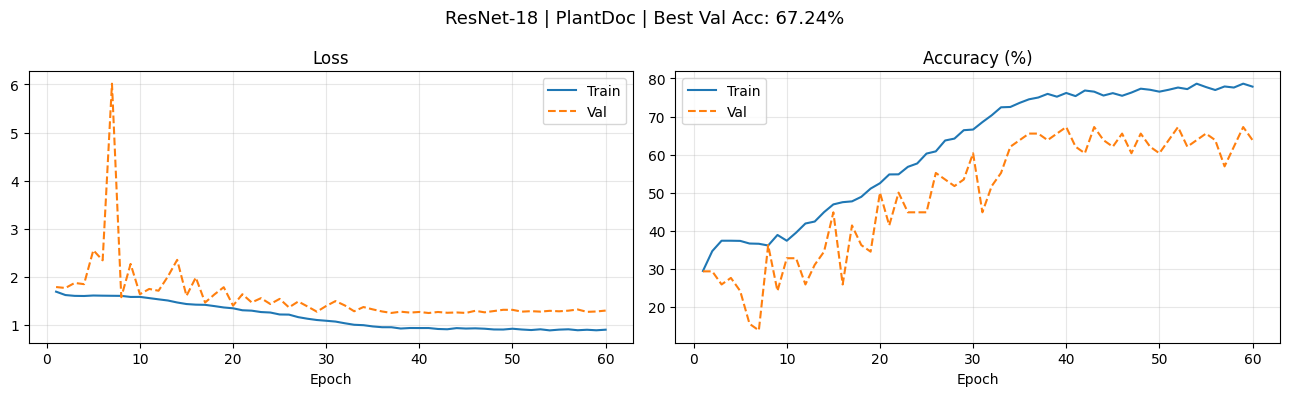

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'],   label='Val', linestyle='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val', linestyle='--')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'ResNet-18 | PlantDoc | Best Val Acc: {best_acc:.2%}', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/PlantDoc/resnet18_curves.png', dpi=150)
plt.show()

In [9]:
checkpoint = torch.load('/content/drive/MyDrive/Datasets/PlantDoc/resnet18_best.pth')
model = ResNet18(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(checkpoint['model_state'])
model.eval()

ResNet18(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): C

In [10]:
test_path = os.path.join(DATA_ROOT, 'test')
eval_path = test_path if os.path.exists(test_path) else os.path.join(DATA_ROOT, 'val')

eval_ds = datasets.ImageFolder(eval_path, transform=val_tf)
eval_dl = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=0, pin_memory=True)

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in eval_dl:
        with autocast():
            out = model(imgs.to(DEVICE))
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(labels)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
overall    = (all_preds == all_labels).float().mean().item()
print(f'\nOverall accuracy on {os.path.basename(eval_path)}: {overall:.4%}\n')

for i, cls in enumerate(eval_ds.classes):
    mask = (all_labels == i)
    acc  = (all_preds[mask] == all_labels[mask]).float().mean().item()
    print(f'  {cls:40s}  {acc:6.2%}  (n={mask.sum().item()})')


Overall accuracy on test: 34.4828%

  Bacterial Spot                            10.00%  (n=10)
  Early Blight                              22.22%  (n=9)
  Healthy                                   50.00%  (n=6)
  Late Blight                               54.55%  (n=11)
  Septoria Leaf Spot                        26.67%  (n=15)
  Yellow Leaf Curl Virus                    57.14%  (n=7)


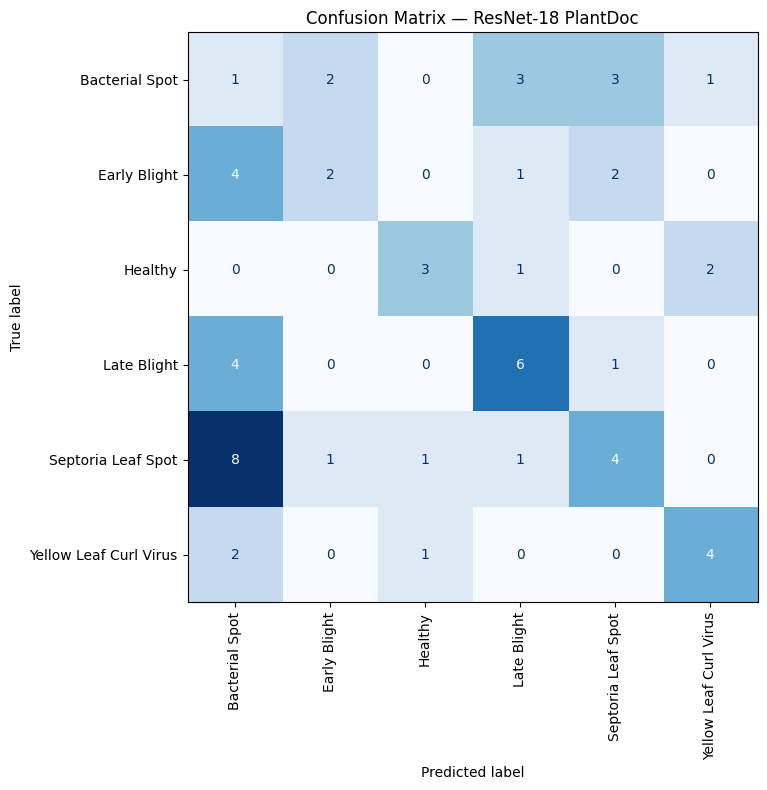

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(all_labels.numpy(), all_preds.numpy())
fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES//2), max(8, NUM_CLASSES//2)))
ConfusionMatrixDisplay(cm, display_labels=eval_ds.classes).plot(
    ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — ResNet-18 PlantDoc')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/PlantDoc/resnet18_cm.png', dpi=120)
plt.show()


In [12]:
from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy(), target_names=eval_ds.classes))

                        precision    recall  f1-score   support

        Bacterial Spot       0.05      0.10      0.07        10
          Early Blight       0.40      0.22      0.29         9
               Healthy       0.60      0.50      0.55         6
           Late Blight       0.50      0.55      0.52        11
    Septoria Leaf Spot       0.40      0.27      0.32        15
Yellow Leaf Curl Virus       0.57      0.57      0.57         7

              accuracy                           0.34        58
             macro avg       0.42      0.37      0.39        58
          weighted avg       0.40      0.34      0.36        58

